# ASSIGNMENT 03 - NEURAL NETWORKS AND REPRESENTATION LEARNING
## Hệ thống 3 - E-commerce Purchase Propensity

**Dataset:** Customer Purchase Behavior Dataset (E-Commerce)  
**Target:** `PurchaseStatus`

**Mục tiêu**
- 3 mô hình Machine Learning cơ bản.
- Baseline MLP, Deeper MLP và Deep Learning 5 Linear Layers.
- So sánh learning rate `0.001` và `0.01`.
- Accuracy, Precision, Recall, F1-score, ROC-AUC.
- Interest Discovery và Learned Representation.

In [1]:
import os, copy, random, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.14.0+cpu
Device: cpu


Shape: (500000, 17)
Columns: ['Age', 'AnnualIncome', 'NumberOfPurchases', 'TimeSpentOnWebsite', 'CustomerTenureYears', 'LastPurchaseDaysAgo', 'Gender', 'ProductCategory', 'PreferredDevice', 'Region', 'ReferralSource', 'CustomerSegment', 'LoyaltyProgram', 'DiscountsAvailed', 'SessionCount', 'CustomerSatisfaction', 'PurchaseStatus']
Missing: 0
Duplicate rows: 0

Target counts:
PurchaseStatus
0    290823
1    209177
Name: count, dtype: int64

Target rate:
PurchaseStatus
0    0.581646
1    0.418354
Name: proportion, dtype: float64


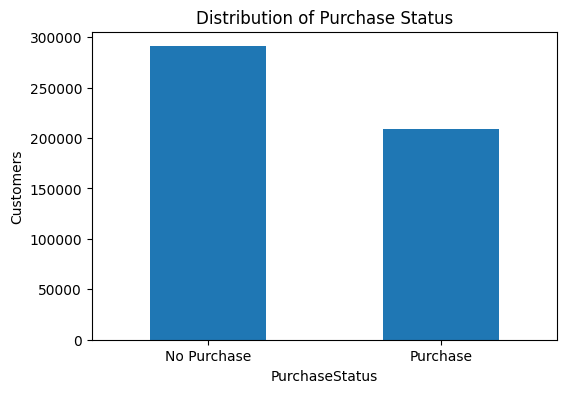

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus
0,37,57722.572411,19,5.908826,1.093430,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1
1,63,21328.925876,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0
2,60,150537.742465,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0
3,19,63508.762549,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0
4,54,100399.558368,19,55.925462,0.197411,92,Male,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0


In [2]:
# 1. Đọc và khám phá dữ liệu
DATA_PATH = Path("Data/customerData.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Không tìm thấy Data/customerData.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

TARGET = "PurchaseStatus"
if TARGET not in df.columns:
    raise ValueError("Dataset không có cột PurchaseStatus")

print("\nTarget counts:")
print(df[TARGET].value_counts().sort_index())
print("\nTarget rate:")
print(df[TARGET].value_counts(normalize=True).sort_index())

plt.figure(figsize=(6, 4))
df[TARGET].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No Purchase", "Purchase"], rotation=0)
plt.ylabel("Customers")
plt.title("Distribution of Purchase Status")
plt.show()

df.head()

In [3]:
# 2. Cleaning các giá trị âm không hợp lệ
df_clean = df.copy()

invalid_nonnegative_cols = [
    "NumberOfPurchases",
    "TimeSpentOnWebsite",
    "CustomerTenureYears",
    "LastPurchaseDaysAgo"
]

for col in invalid_nonnegative_cols:
    if col in df_clean.columns:
        invalid_count = (df_clean[col] < 0).sum()
        print(col, "invalid negative:", int(invalid_count))
        df_clean.loc[df_clean[col] < 0, col] = np.nan

print("\nMissing after cleaning:")
print(df_clean.isnull().sum().sort_values(ascending=False).head(10))

NumberOfPurchases invalid negative: 394
TimeSpentOnWebsite invalid negative: 8472
CustomerTenureYears invalid negative: 11145
LastPurchaseDaysAgo invalid negative: 7907

Missing after cleaning:
CustomerTenureYears    11145
TimeSpentOnWebsite      8472
LastPurchaseDaysAgo     7907
NumberOfPurchases        394
Age                        0
AnnualIncome               0
Gender                     0
ProductCategory            0
PreferredDevice            0
Region                     0
dtype: int64


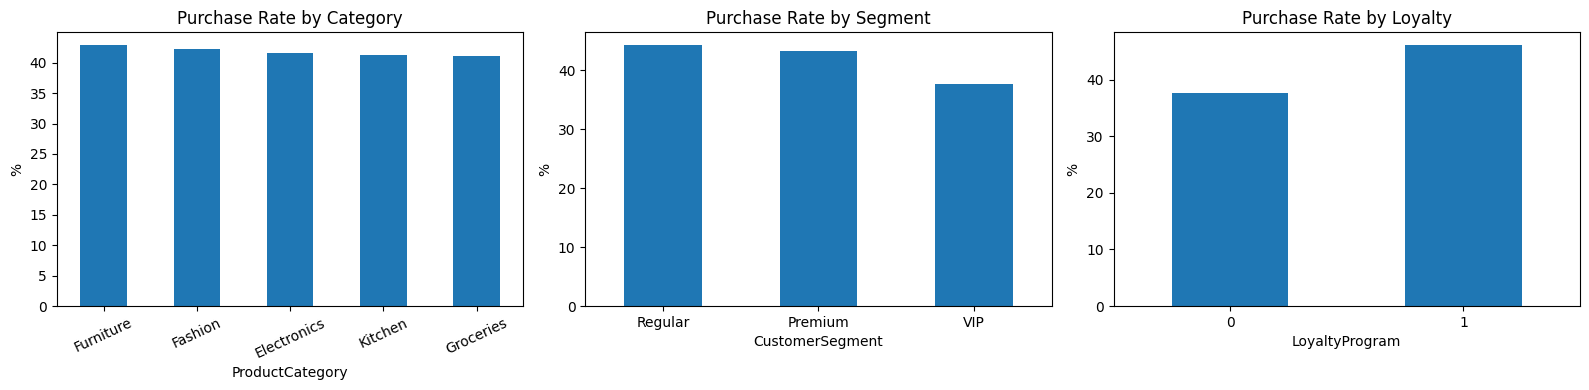

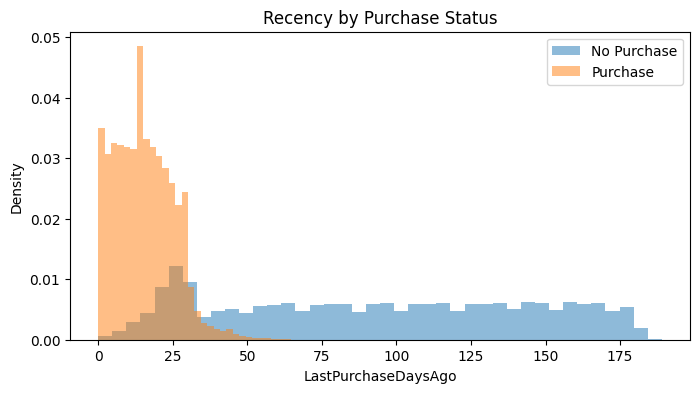

In [4]:
# 3. Interest Discovery
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if "ProductCategory" in df_clean.columns:
    category_rate = (
        df_clean.groupby("ProductCategory")[TARGET]
        .mean().sort_values(ascending=False) * 100
    )
    category_rate.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Purchase Rate by Category")
    axes[0].set_ylabel("%")
    axes[0].tick_params(axis="x", rotation=25)
else:
    axes[0].axis("off")

segment_col = next(
    (c for c in ["CustomerSegment", "Segment"] if c in df_clean.columns),
    None
)

if segment_col:
    segment_rate = (
        df_clean.groupby(segment_col)[TARGET]
        .mean().sort_values(ascending=False) * 100
    )
    segment_rate.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Purchase Rate by Segment")
    axes[1].set_ylabel("%")
    axes[1].tick_params(axis="x", rotation=0)
else:
    axes[1].axis("off")

if "LoyaltyProgram" in df_clean.columns:
    loyalty_rate = (
        df_clean.groupby("LoyaltyProgram")[TARGET]
        .mean().sort_index() * 100
    )
    loyalty_rate.plot(kind="bar", ax=axes[2])
    axes[2].set_title("Purchase Rate by Loyalty")
    axes[2].set_ylabel("%")
    axes[2].tick_params(axis="x", rotation=0)
else:
    axes[2].axis("off")

plt.tight_layout()
plt.show()

if "LastPurchaseDaysAgo" in df_clean.columns:
    plt.figure(figsize=(8, 4))

    for label in [0, 1]:
        values = df_clean.loc[
            df_clean[TARGET] == label,
            "LastPurchaseDaysAgo"
        ].dropna()

        plt.hist(
            values, bins=40, alpha=0.5, density=True,
            label="Purchase" if label == 1 else "No Purchase"
        )

    plt.xlabel("LastPurchaseDaysAgo")
    plt.ylabel("Density")
    plt.title("Recency by Purchase Status")
    plt.legend()
    plt.show()

In [5]:
# 4. X/y, feature groups và chia 70/15/15
X = df_clean.drop(columns=[TARGET]).copy()
y = pd.to_numeric(df_clean[TARGET], errors="raise").astype(int)

BINARY_FEATURES = ["LoyaltyProgram"] if "LoyaltyProgram" in X.columns else []

cat_candidates = [
    "Gender", "ProductCategory",
    "PreferredDevice", "Device",
    "Region", "ReferralSource",
    "CustomerSegment", "Segment"
]

CAT_FEATURES = [c for c in cat_candidates if c in X.columns]

for col in X.columns:
    if col in BINARY_FEATURES or col in CAT_FEATURES:
        continue
    if pd.api.types.is_object_dtype(X[col]) or str(X[col].dtype) == "category":
        CAT_FEATURES.append(col)

NUM_FEATURES = [
    c for c in X.columns
    if c not in CAT_FEATURES and c not in BINARY_FEATURES
]

for col in CAT_FEATURES:
    X[col] = X[col].astype("object")

print("Numerical:", NUM_FEATURES)
print("Binary:", BINARY_FEATURES)
print("Categorical:", CAT_FEATURES)
print("Total raw features:", X.shape[1])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Numerical: ['Age', 'AnnualIncome', 'NumberOfPurchases', 'TimeSpentOnWebsite', 'CustomerTenureYears', 'LastPurchaseDaysAgo', 'DiscountsAvailed', 'SessionCount', 'CustomerSatisfaction']
Binary: ['LoyaltyProgram']
Categorical: ['Gender', 'ProductCategory', 'PreferredDevice', 'Region', 'ReferralSource', 'CustomerSegment']
Total raw features: 16

Train: (350000, 16)
Validation: (75000, 16)
Test: (75000, 16)


In [6]:
# 5. Preprocessing
transformers = []

if NUM_FEATURES:
    transformers.append(
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUM_FEATURES
        )
    )

if BINARY_FEATURES:
    transformers.append(
        (
            "binary",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent"))
            ]),
            BINARY_FEATURES
        )
    )

if CAT_FEATURES:
    transformers.append(
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True
                ))
            ]),
            CAT_FEATURES
        )
    )

preprocessor = ColumnTransformer(
    transformers=transformers,
    sparse_threshold=1.0
)

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

print("Raw train:", X_train.shape)
print("Encoded train:", X_train_t.shape)
print("Encoded dimension:", X_train_t.shape[1])

Raw train: (350000, 16)
Encoded train: (350000, 32)
Encoded dimension: 32


In [7]:
# 6. Ba mô hình Machine Learning cơ bản
def cls_metrics(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score)
    }

logistic_model = LogisticRegression(max_iter=1000, random_state=SEED)
svm_model = LinearSVC(random_state=SEED, max_iter=5000, dual="auto")
rf_model = RandomForestClassifier(
    n_estimators=80, max_depth=20, min_samples_leaf=2,
    random_state=SEED, n_jobs=-1
)

logistic_model.fit(X_train_t, y_train)
svm_model.fit(X_train_t, y_train)
rf_model.fit(X_train_t, y_train)

ml_models = {
    "Logistic Regression": (
        logistic_model.predict(X_test_t),
        logistic_model.predict_proba(X_test_t)[:, 1]
    ),
    "Linear SVM": (
        svm_model.predict(X_test_t),
        svm_model.decision_function(X_test_t)
    ),
    "Random Forest": (
        rf_model.predict(X_test_t),
        rf_model.predict_proba(X_test_t)[:, 1]
    )
}

ml_results = pd.DataFrame([
    {"Model": name, **cls_metrics(y_test, pred, score)}
    for name, (pred, score) in ml_models.items()
])

ml_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.9168,0.8835,0.9227,0.9027,0.9769
1,Linear SVM,0.9165,0.8815,0.9247,0.9026,0.9769
2,Random Forest,0.9168,0.8737,0.9364,0.9040,0.9758


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.9168,0.8835,0.9227,0.9027,0.9769
1,Linear SVM,0.9165,0.8815,0.9247,0.9026,0.9769
2,Random Forest,0.9168,0.8737,0.9364,0.9040,0.9758


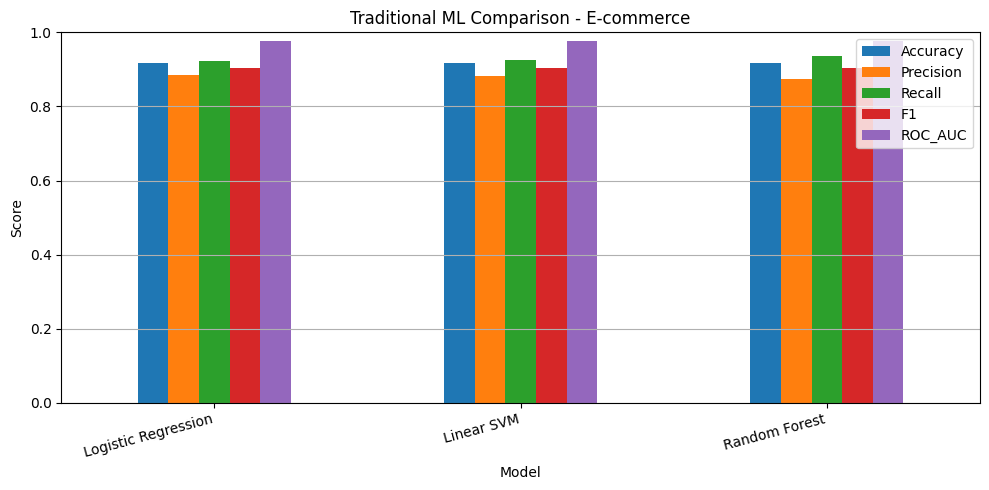

In [8]:
# 7. So sánh 3 ML models
display(ml_results.round(4))

ml_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].plot(kind="bar", figsize=(10, 5))

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Traditional ML Comparison - E-commerce")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [9]:
# 8. Chuẩn bị dữ liệu cho PyTorch
def to_dense_float32(matrix):
    if hasattr(matrix, "toarray"):
        return matrix.toarray().astype(np.float32)
    return np.asarray(matrix, dtype=np.float32)

X_train_dense = to_dense_float32(X_train_t)
X_val_dense = to_dense_float32(X_val_t)
X_test_dense = to_dense_float32(X_test_t)

X_train_tensor = torch.tensor(X_train_dense, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_dense, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_dense, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.long)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

BATCH_SIZE = 2048

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def make_train_loader(seed=SEED):
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        shuffle=True, generator=g
    )

print("Tensor train:", X_train_tensor.shape)

Tensor train: torch.Size([350000, 32])


In [10]:
# 9. Các kiến trúc Neural Network
INPUT_DIM = X_train_dense.shape[1]

class BaselineMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

class DeeperMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(x)

class DeepMLP5(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 8)
        self.fc5 = nn.Linear(8, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2))
        h4 = self.relu(self.fc4(h3))
        return self.fc5(h4)

    def extract_features(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2))
        h4 = self.relu(self.fc4(h3))
        return h1, h2, h3, h4

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for m in [BaselineMLP(INPUT_DIM), DeeperMLP(INPUT_DIM), DeepMLP5(INPUT_DIM)]:
    print(m.__class__.__name__, "-", count_parameters(m), "parameters")

BaselineMLP - 2242 parameters
DeeperMLP - 4258 parameters
DeepMLP5 - 4874 parameters


In [11]:
# 10. Hàm train/evaluate dùng chung
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = correct = total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        pred = outputs.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total

def evaluate_dl(model, loader, criterion):
    model.eval()
    total_loss = total = 0
    preds, targets, scores = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)

            prob = torch.softmax(outputs, dim=1)[:, 1]
            pred = outputs.argmax(dim=1)

            total_loss += loss.item() * xb.size(0)
            total += yb.size(0)

            preds.extend(pred.cpu().numpy())
            targets.extend(yb.cpu().numpy())
            scores.extend(prob.cpu().numpy())

    metrics = cls_metrics(targets, preds, scores)
    metrics["Loss"] = total_loss / total
    return metrics, np.array(preds), np.array(scores)

def train_model(model, lr, epochs=20, seed=SEED):
    torch.manual_seed(seed)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loader = make_train_loader(seed)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [], "val_f1": []
    }

    best_f1, best_state, best_epoch = -1, None, 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, loader, criterion, optimizer)
        val_metrics, _, _ = evaluate_dl(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["Loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_metrics["Accuracy"])
        history["val_f1"].append(val_metrics["F1"])

        if val_metrics["F1"] > best_f1:
            best_f1 = val_metrics["F1"]
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch+1:02d}/{epochs} | "
                f"Train Loss {train_loss:.4f} | "
                f"Val Loss {val_metrics['Loss']:.4f} | "
                f"Val F1 {val_metrics['F1']:.4f}"
            )

    model.load_state_dict(best_state)
    return model, history, best_epoch, best_f1

def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(history["train_loss"], label="Train")
    ax[0].plot(history["val_loss"], label="Validation")
    ax[0].set_title(f"{title} - Loss")
    ax[0].legend()
    ax[0].grid()

    ax[1].plot(history["train_acc"], label="Train")
    ax[1].plot(history["val_acc"], label="Validation")
    ax[1].set_title(f"{title} - Accuracy")
    ax[1].legend()
    ax[1].grid()

    plt.tight_layout()
    plt.show()

## 11. Cấu hình thí nghiệm Neural Network

- Batch size: **2048**
- Epochs: **20**
- Loss: **CrossEntropyLoss**
- Optimizer: **Adam**
- Activation: **ReLU**
- Model selection: **Validation F1-score**

Experiments:
1. Baseline: `d → 64 → 2`
2. Deeper: `d → 64 → 32 → 2`
3. 5-Layer: `d → 64 → 32 → 16 → 8 → 2`, so sánh LR `0.001` và `0.01`.

In [12]:
# 12. Experiment 1 - Baseline
baseline_model, baseline_history, baseline_epoch, baseline_val_f1 = train_model(
    BaselineMLP(INPUT_DIM), lr=0.001
)

print("Best epoch:", baseline_epoch)
print("Best validation F1:", round(baseline_val_f1, 4))

Epoch 05/20 | Train Loss 0.1881 | Val Loss 0.1876 | Val F1 0.9032
Epoch 10/20 | Train Loss 0.1874 | Val Loss 0.1867 | Val F1 0.9036
Epoch 15/20 | Train Loss 0.1864 | Val Loss 0.1860 | Val F1 0.9039
Epoch 20/20 | Train Loss 0.1857 | Val Loss 0.1860 | Val F1 0.9045
Best epoch: 18
Best validation F1: 0.9048


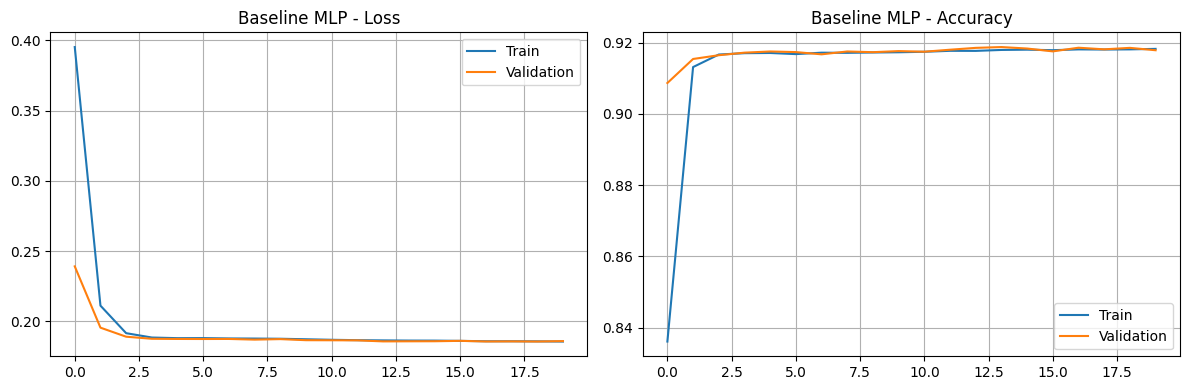

In [13]:
plot_history(baseline_history, "Baseline MLP")

In [14]:
# 13. Experiment 2 - Deeper
deeper_model, deeper_history, deeper_epoch, deeper_val_f1 = train_model(
    DeeperMLP(INPUT_DIM), lr=0.001
)

print("Best epoch:", deeper_epoch)
print("Best validation F1:", round(deeper_val_f1, 4))

Epoch 05/20 | Train Loss 0.1879 | Val Loss 0.1875 | Val F1 0.9032
Epoch 10/20 | Train Loss 0.1864 | Val Loss 0.1862 | Val F1 0.9039
Epoch 15/20 | Train Loss 0.1859 | Val Loss 0.1856 | Val F1 0.9044
Epoch 20/20 | Train Loss 0.1854 | Val Loss 0.1858 | Val F1 0.9043
Best epoch: 13
Best validation F1: 0.9052


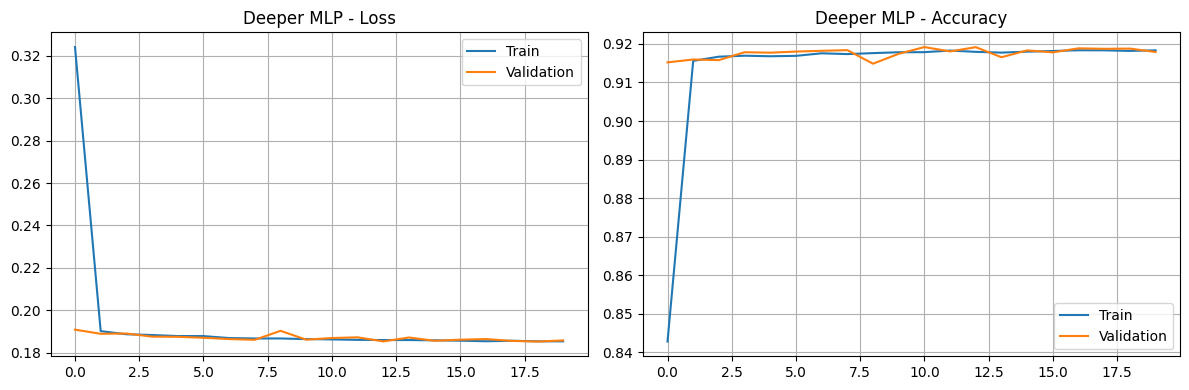

In [15]:
plot_history(deeper_history, "Deeper MLP")

In [16]:
# 14. Experiment 3 - 5 Layers, hai learning rate
deep5_lr001, hist_lr001, epoch_lr001, val_f1_lr001 = train_model(
    DeepMLP5(INPUT_DIM), lr=0.001
)

deep5_lr01, hist_lr01, epoch_lr01, val_f1_lr01 = train_model(
    DeepMLP5(INPUT_DIM), lr=0.01
)

print("LR 0.001 -> Val F1:", round(val_f1_lr001, 4))
print("LR 0.01  -> Val F1:", round(val_f1_lr01, 4))

if val_f1_lr001 >= val_f1_lr01:
    final_dl_model, final_dl_lr = deep5_lr001, 0.001
else:
    final_dl_model, final_dl_lr = deep5_lr01, 0.01

Epoch 05/20 | Train Loss 0.1881 | Val Loss 0.1878 | Val F1 0.9027
Epoch 10/20 | Train Loss 0.1873 | Val Loss 0.1872 | Val F1 0.9030
Epoch 15/20 | Train Loss 0.1864 | Val Loss 0.1867 | Val F1 0.9037
Epoch 20/20 | Train Loss 0.1855 | Val Loss 0.1859 | Val F1 0.9044
Epoch 05/20 | Train Loss 0.1888 | Val Loss 0.1875 | Val F1 0.9014
Epoch 10/20 | Train Loss 0.1856 | Val Loss 0.1850 | Val F1 0.9032
Epoch 15/20 | Train Loss 0.1836 | Val Loss 0.1829 | Val F1 0.9051
Epoch 20/20 | Train Loss 0.1814 | Val Loss 0.1807 | Val F1 0.9046
LR 0.001 -> Val F1: 0.9046
LR 0.01  -> Val F1: 0.9051


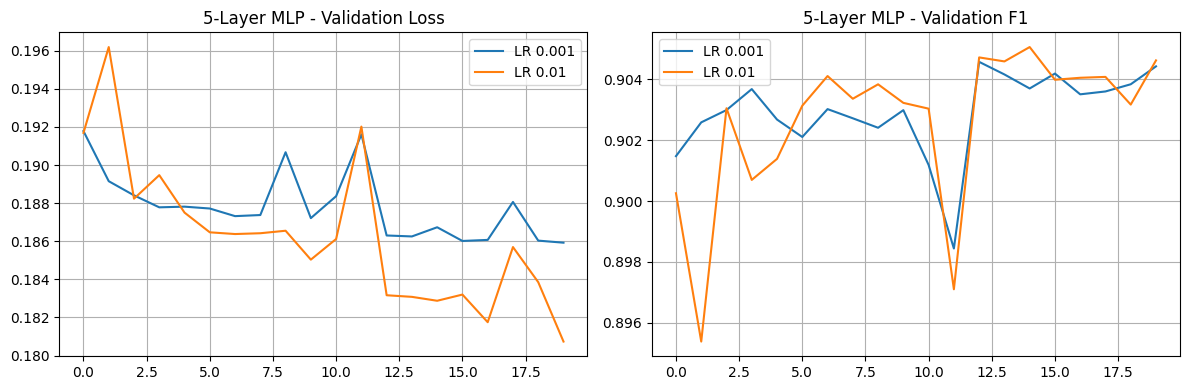

In [17]:
# 15. So sánh learning rate
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist_lr001["val_loss"], label="LR 0.001")
ax[0].plot(hist_lr01["val_loss"], label="LR 0.01")
ax[0].set_title("5-Layer MLP - Validation Loss")
ax[0].legend()
ax[0].grid()

ax[1].plot(hist_lr001["val_f1"], label="LR 0.001")
ax[1].plot(hist_lr01["val_f1"], label="LR 0.01")
ax[1].set_title("5-Layer MLP - Validation F1")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

In [18]:
# 16. Đánh giá Neural Network trên Test
criterion_test = nn.CrossEntropyLoss()

dl_models = [
    ("Baseline MLP", baseline_model, f"{INPUT_DIM}-64-2", 0.001, baseline_epoch),
    ("Deeper MLP", deeper_model, f"{INPUT_DIM}-64-32-2", 0.001, deeper_epoch),
    ("5-Layer MLP (0.001)", deep5_lr001, f"{INPUT_DIM}-64-32-16-8-2", 0.001, epoch_lr001),
    ("5-Layer MLP (0.01)", deep5_lr01, f"{INPUT_DIM}-64-32-16-8-2", 0.01, epoch_lr01),
]

dl_rows = []
dl_predictions = {}

for name, model, arch, lr, epoch in dl_models:
    metrics, pred, score = evaluate_dl(model, test_loader, criterion_test)
    dl_predictions[name] = pred
    dl_rows.append({
        "Model": name,
        "Architecture": arch,
        "Parameters": count_parameters(model),
        "Learning Rate": lr,
        "Best Epoch": epoch,
        **metrics
    })

dl_results = pd.DataFrame(dl_rows)
dl_results.round(4)

,Model,Architecture,Parameters,Learning Rate,Best Epoch,Accuracy,Precision,Recall,F1,ROC_AUC,Loss
0,Baseline MLP,32-64-2,2242,0.001,18,0.9171,0.8798,0.9289,0.9037,0.9772,0.1879
1,Deeper MLP,32-64-32-2,4258,0.001,13,0.9174,0.8862,0.9209,0.9032,0.9771,0.1878
2,5-Layer MLP (0.001),32-64-32-16-8-2,4874,0.001,13,0.9171,0.8823,0.9254,0.9033,0.9770,0.1884
3,5-Layer MLP (0.01),32-64-32-16-8-2,4874,0.010,15,0.9181,0.8870,0.9216,0.9040,0.9776,0.1848


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.9168,0.8737,0.9364,0.9040,0.9758
6,5-Layer MLP (0.01),0.9181,0.8870,0.9216,0.9040,0.9776
3,Baseline MLP,0.9171,0.8798,0.9289,0.9037,0.9772
5,5-Layer MLP (0.001),0.9171,0.8823,0.9254,0.9033,0.9770
4,Deeper MLP,0.9174,0.8862,0.9209,0.9032,0.9771
0,Logistic Regression,0.9168,0.8835,0.9227,0.9027,0.9769
1,Linear SVM,0.9165,0.8815,0.9247,0.9026,0.9769


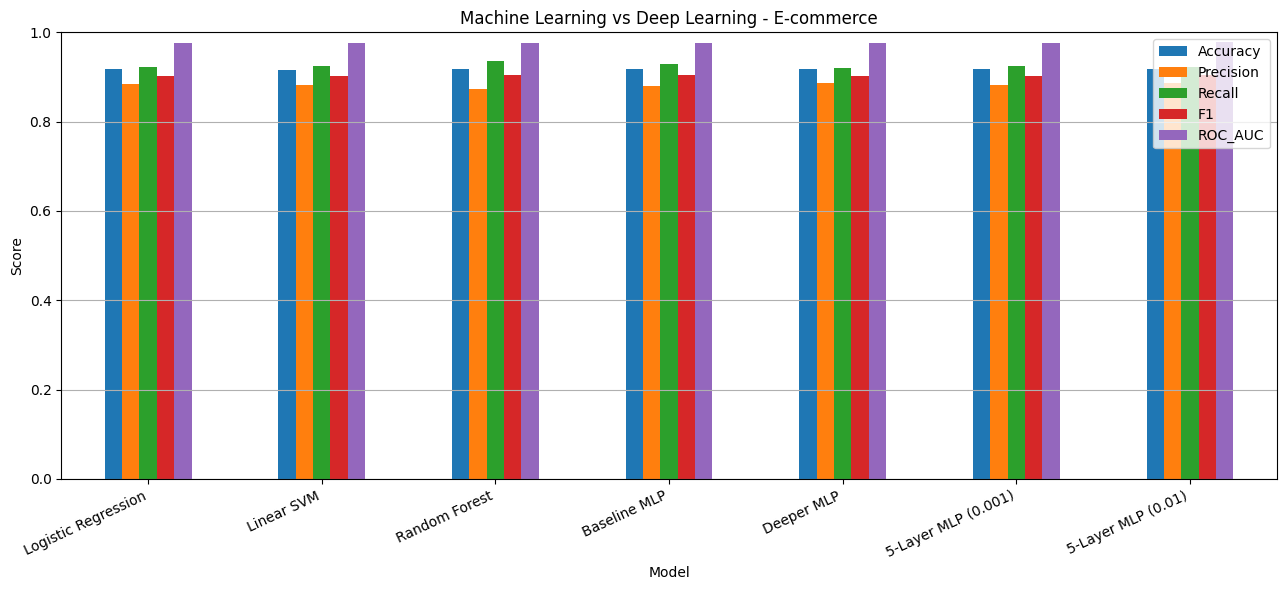

In [19]:
# 17. Tổng hợp ML và DL
all_results = pd.concat(
    [
        ml_results,
        dl_results[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]]
    ],
    ignore_index=True
)

display(all_results.sort_values("F1", ascending=False).round(4))

all_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].plot(kind="bar", figsize=(13, 6))

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Machine Learning vs Deep Learning - E-commerce")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [20]:
# Best Result
best_model = all_results.loc[
    all_results["F1"].idxmax()
]

print("BEST MODEL")
print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.4f}")
print(f"Precision : {best_model['Precision']:.4f}")
print(f"Recall    : {best_model['Recall']:.4f}")
print(f"F1-score  : {best_model['F1']:.4f}")
print(f"ROC-AUC   : {best_model['ROC_AUC']:.4f}")

BEST MODEL
Model     : Random Forest
Accuracy  : 0.9168
Precision : 0.8737
Recall    : 0.9364
F1-score  : 0.9040
ROC-AUC   : 0.9758


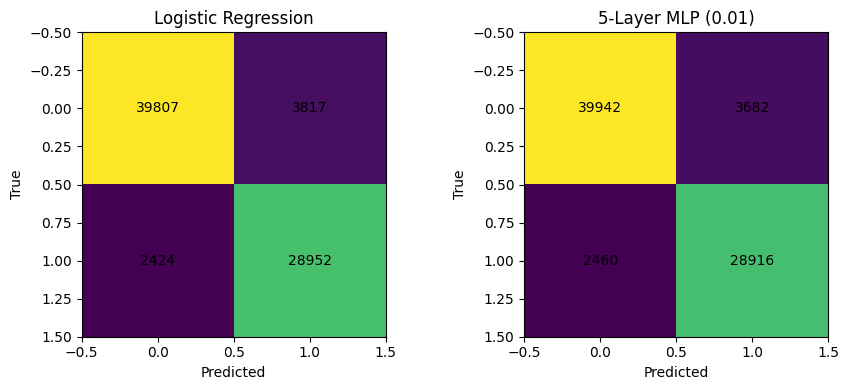

In [21]:
# 18. Confusion Matrix: Logistic Regression + final 5-layer
final_name = "5-Layer MLP (0.001)" if final_dl_lr == 0.001 else "5-Layer MLP (0.01)"

cm_items = [
    ("Logistic Regression", ml_models["Logistic Regression"][0]),
    (final_name, dl_predictions[final_name]),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (name, pred) in zip(axes, cm_items):
    cm = confusion_matrix(y_test, pred)
    ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

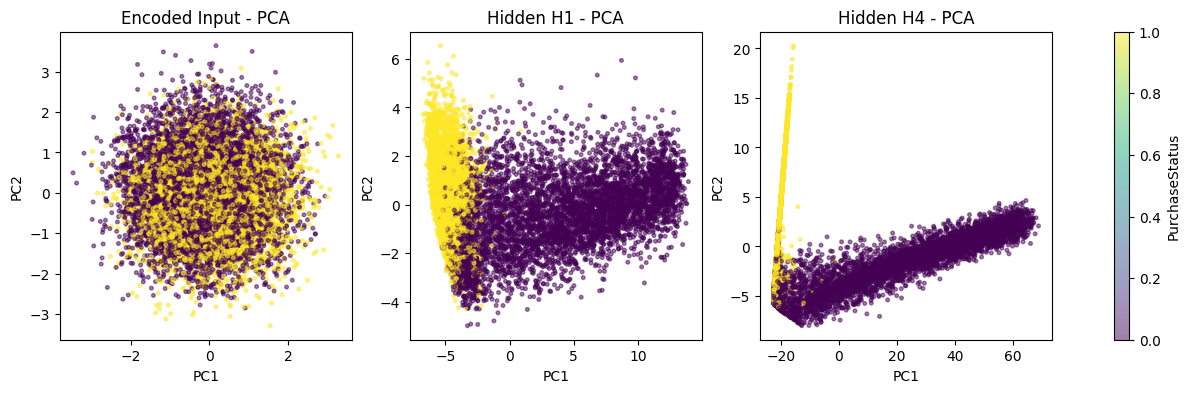

Encoded Input: (75000, 32)
H1: (75000, 64)
H4: (75000, 8)


In [22]:
# 19. Learned Representation + PCA
final_dl_model.eval()

with torch.no_grad():
    h1, h2, h3, h4 = final_dl_model.extract_features(X_test_tensor.to(device))

h1_np = h1.cpu().numpy()
h4_np = h4.cpu().numpy()

N = min(10000, len(X_test_dense))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_test_dense), size=N, replace=False)
y_pca = y_test.to_numpy()[idx]

representations = [
    ("Encoded Input", X_test_dense[idx]),
    ("Hidden H1", h1_np[idx]),
    ("Hidden H4", h4_np[idx]),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, rep) in zip(axes, representations):
    pca_2d = PCA(n_components=2).fit_transform(rep)
    sc = ax.scatter(
        pca_2d[:, 0], pca_2d[:, 1],
        c=y_pca, s=7, alpha=0.5
    )
    ax.set_title(f"{name} - PCA")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

fig.colorbar(sc, ax=axes.ravel().tolist(), label="PurchaseStatus")
plt.show()

print("Encoded Input:", X_test_dense.shape)
print("H1:", h1_np.shape)
print("H4:", h4_np.shape)

In [23]:
# 20. Lưu mô hình
os.makedirs("models", exist_ok=True)

torch.save(
    final_dl_model.state_dict(),
    "models/ecommerce_deep_mlp_5layers.pth"
)

joblib.dump(
    preprocessor,
    "models/ecommerce_preprocessor.joblib"
)

joblib.dump(
    {
        "input_dim": INPUT_DIM,
        "architecture": f"{INPUT_DIM}-64-32-16-8-2",
        "learning_rate": final_dl_lr,
        "target": TARGET,
        "raw_features": X.columns.tolist()
    },
    "models/ecommerce_model_info.joblib"
)

print("Selected 5-layer LR:", final_dl_lr)
print("Model saved:", os.path.exists("models/ecommerce_deep_mlp_5layers.pth"))

Selected 5-layer LR: 0.01
Model saved: True


## 21. Business Interpretation

Purchase Propensity Prediction có thể hỗ trợ:
- targeted promotion;
- phân bổ voucher;
- retention campaign;
- ưu tiên khách hàng có propensity mua cao.

Interest Discovery bổ sung góc nhìn theo `ProductCategory`, customer segment, `LoyaltyProgram` và recency.

**Lưu ý:** dataset này không có comment/review text, nên Interest Discovery dựa trên tabular data và EDA, không phải NLP.

## 22. Kết luận

Notebook đã so sánh 3 mô hình Machine Learning với các Neural Network cho bài toán Purchase Propensity Prediction.

Deep Learning 5 Linear Layers:

**Encoded Input → 64 → 32 → 16 → 8 → 2**

PCA được dùng để trực quan hóa learned representation qua các hidden layers.